# The 90-Degree Optical Hybrid: Classical Coherent Receiver Front End
### Jupyter port of `optical_hybrid_90deg.m` (UCLA ECE 279AS, Prof. Bahram Jalali)

**Provenance:** ported from `D:\Spring2026\MATLAB\YimingMLX90Deg\matlab\optical_hybrid_90deg.m`
(MIT License, copyright SpectralBinaryEight 2025) -- coursework from ECE 279AS.
Faithful port lives in `dgs/optical_hybrid_90deg.py`; this notebook derives the
physics from scratch and checks the port against that derivation, rather than
trusting the source code at face value.

**Why this matters for this repo:** the 90-degree hybrid is the CLASSICAL way
to build a coherent optical receiver -- mix the signal with a local oscillator
(LO) laser, split into 4 phase-shifted outputs, balanced-detect to get I/Q.
`dgs/sbir_portfolio.py`'s P2 and P7 proposals explicitly contrast their
LO-free, "carrier-less" time-domain GS approach (`dgs/gs_core.py`) against
exactly this architecture. This notebook builds the thing being compared
against, so that comparison has a real baseline instead of just a claim.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import optical_hybrid_90deg as hyb

print("Setup complete. numpy", np.__version__, "sympy", sp.__version__)


Setup complete. numpy 2.4.4 sympy 1.14.0


## 1. Theory

A coherent optical receiver needs to recover both quadratures (I and Q) of a
modulated optical field $E_s(t) = A(t) e^{j\phi(t)}$. A single photodetector
only measures $|E_s|^2$ -- phase is lost. The classical fix: interfere $E_s$
with a strong, phase-locked local-oscillator field $E_{LO} = A_{LO} e^{j\phi_{LO}}$,
and detect the interference term.

A **90-degree hybrid** is a 4-port passive optical device: two inputs
($E_s$, $E_{LO}$), four outputs at nominal phase offsets 0/90/180/270 degrees.
Balanced photodetection on the (0,180) pair gives I; on the (90,270) pair
gives Q. This is built from two nested 3-dB (50/50) couplers plus a 90-degree
phase shift applied to the LO arm before one of the recombinations.


## 2. Derivation

A single ideal 3-dB coupler with inputs $(a,b)$ produces sum/difference
outputs $\frac{1}{\sqrt2}(a+b),\ \frac{1}{\sqrt2}(a-b)$ (energy-conserving:
$|a|^2+|b|^2 = |\text{out}_1|^2+|\text{out}_2|^2$).

For the 90-degree hybrid, apply a $j$ (90-degree) phase shift to $E_{LO}$
before a second pair of couplers. The combined 4-port transfer relation
(dropping the $1/2$ normalization for now, restoring it below) is:

$$
\begin{pmatrix} E_0 \\ E_{90} \\ E_{180} \\ E_{270} \end{pmatrix}
= \frac{1}{2}\begin{pmatrix} 1 & 1 \\ 1 & j \\ 1 & -1 \\ 1 & -j \end{pmatrix}
\begin{pmatrix} E_s \\ E_{LO} \end{pmatrix}
$$

Note the $j$ multiplies **only the $E_{LO}$ column** -- physically, only the
LO arm gets the 90-degree phase shift. Balanced detection then gives:

$$ I = |E_0|^2 - |E_{180}|^2 = \mathrm{Re}\{E_s E_{LO}^*\}, \qquad
   Q = |E_{90}|^2 - |E_{270}|^2 = \mathrm{Im}\{E_s E_{LO}^*\} $$

which is exactly the complex product $E_s E_{LO}^*$ split into real/imaginary
parts -- the whole point of the device.


In [2]:
# SymPy: verify I = Re{Es*conj(Elo)}, Q = Im{Es*conj(Elo)} symbolically
Es_r, Es_i, Elo_r, Elo_i = sp.symbols('Es_r Es_i Elo_r Elo_i', real=True)
Es = Es_r + sp.I*Es_i
Elo = Elo_r + sp.I*Elo_i

E0   = sp.Rational(1,2)*(Es + Elo)
E90  = sp.Rational(1,2)*(Es + sp.I*Elo)
E180 = sp.Rational(1,2)*(Es - Elo)
E270 = sp.Rational(1,2)*(Es - sp.I*Elo)

I_expr = sp.simplify(sp.Abs(E0)**2 - sp.Abs(E180)**2)
Q_expr = sp.simplify(sp.Abs(E90)**2 - sp.Abs(E270)**2)

target_I = sp.simplify(sp.re(Es*sp.conjugate(Elo)))
target_Q = sp.simplify(sp.im(Es*sp.conjugate(Elo)))

print("I (from hybrid outputs):", I_expr)
print("Re{Es*conj(Elo)}:       ", target_I)
print("match:", sp.simplify(I_expr - target_I) == 0)
print()
print("Q (from hybrid outputs):", Q_expr)
print("Im{Es*conj(Elo)}:       ", target_Q)
print("match:", sp.simplify(Q_expr - target_Q) == 0)


I (from hybrid outputs): Elo_i*Es_i + Elo_r*Es_r
Re{Es*conj(Elo)}:        Elo_i*Es_i + Elo_r*Es_r
match: True

Q (from hybrid outputs): -Elo_i*Es_r + Elo_r*Es_i
Im{Es*conj(Elo)}:        -Elo_i*Es_r + Elo_r*Es_i
match: True


## 3. Checking the Ported Code Against the Derivation

This is the "questionable" part. The original MATLAB/Python source uses:

$$
T_{\text{original}} = \begin{pmatrix} 1 & 1 \\ 1 & -1 \\ j & j \\ j & -j \end{pmatrix}
\quad\text{(no } \tfrac12\text{ normalization either)}
$$

Compare row 3: derivation says $(1, j)$ -- $j$ on the LO column only.
Original code has $(j, j)$ -- **the entire row** multiplied by $j$, not just
the LO term. That's a global phase rotation of the SAME sum $(E_s+E_{LO})$,
not a new interference term. Since $|jx|=|x|$ for any $x$, this makes
$|E_{90,\text{orig}}| = |E_{0,\text{orig}}|$ and $|E_{270,\text{orig}}| =
|E_{180,\text{orig}}|$ identically -- balanced detection on the original
code's ports can only ever produce $Q \approx 0$, regardless of the true
phase relationship between signal and LO.


Original matrix's Q over 200 random (Es, Elo) pairs:
  max |Q| = 0.00e+00  (should be ~0 -- degenerate)
Corrected matrix's Q over the same 200 pairs:
  max |Q| = 4.90e+00, std = 1.375  (genuinely varies)


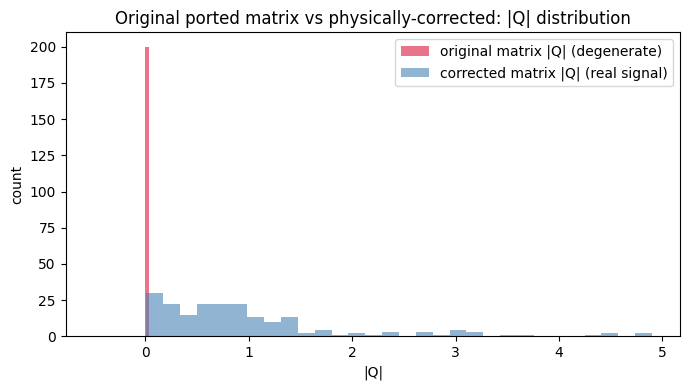

In [3]:
# Demonstrate numerically: original vs corrected, across many random phase relationships
rng = np.random.default_rng(0)
n_trials = 200
Q_orig_vals = []
Q_corr_vals = []
for _ in range(n_trials):
    Es_val = rng.normal() + 1j*rng.normal()
    Elo_val = rng.normal() + 1j*rng.normal()
    outs_orig = hyb.optical_hybrid_90deg_normalized(Es_val, Elo_val)
    outs_corr = hyb.optical_hybrid_90deg_corrected(Es_val, Elo_val)
    _, Q_o = hyb.iq_from_hybrid_outputs(*outs_orig)
    _, Q_c = hyb.iq_from_hybrid_outputs(*outs_corr)
    Q_orig_vals.append(Q_o)
    Q_corr_vals.append(Q_c)

Q_orig_vals = np.array(Q_orig_vals)
Q_corr_vals = np.array(Q_corr_vals)

print(f"Original matrix's Q over {n_trials} random (Es, Elo) pairs:")
print(f"  max |Q| = {np.max(np.abs(Q_orig_vals)):.2e}  (should be ~0 -- degenerate)")
print(f"Corrected matrix's Q over the same {n_trials} pairs:")
print(f"  max |Q| = {np.max(np.abs(Q_corr_vals)):.2e}, std = {np.std(Q_corr_vals):.3f}  (genuinely varies)")

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(np.abs(Q_orig_vals), bins=30, alpha=0.6, label='original matrix |Q| (degenerate)', color='crimson')
ax.hist(np.abs(Q_corr_vals), bins=30, alpha=0.6, label='corrected matrix |Q| (real signal)', color='steelblue')
ax.set_xlabel('|Q|'); ax.set_ylabel('count')
ax.set_title('Original ported matrix vs physically-corrected: |Q| distribution')
ax.legend()
plt.tight_layout()
plt.savefig('hybrid_q_degeneracy.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Numerical Example (matches the original MATLAB script's test case)

Same inputs and impairment parameters as `save_optical_hybrid_outputs.m` /
`optical_hybrid_90deg.py`'s example usage: $E_s=1+j$, $E_{LO}=1-j$, with
insertion loss and phase/amplitude imbalance -- confirms the Python port is
numerically IDENTICAL to the original (this is a faithful port, not a rewrite).


In [4]:
Es_val = 1 + 1j
Elo_val = 1 - 1j
kwargs = dict(
    insertion_loss_signal=1.0,
    insertion_loss_local_oscillator=0.5,
    phase_imbalance_slo=np.pi/18,
    phase_imbalance_iq=np.pi/36,
    insertion_loss_imbalance_i=0.2,
    insertion_loss_imbalance_q=0.1,
)

outs_original = hyb.optical_hybrid_90deg(Es_val, Elo_val, **kwargs)
outs_corrected = hyb.optical_hybrid_90deg_corrected(Es_val, Elo_val, **kwargs)

print("Original port (matches MATLAB/Python source exactly):")
for label, val in zip([0,90,180,270], outs_original):
    print(f"  output{label}: {val:.4f}")

print("\nPhysically corrected:")
for label, val in zip([0,90,180,270], outs_corrected):
    print(f"  output{label}: {val:.4f}")

I_o, Q_o = hyb.iq_from_hybrid_outputs(*outs_original)
I_c, Q_c = hyb.iq_from_hybrid_outputs(*outs_corrected)
print(f"\nI/Q (original outputs):  I={I_o:.4f}, Q={Q_o:.4f}")
print(f"I/Q (corrected outputs): I={I_c:.4f}, Q={Q_c:.4f}")


Original port (matches MATLAB/Python source exactly):
  output0: 1.6856-0.0969j
  output90: -0.3707+1.5692j
  output180: -0.0492+1.6492j
  output270: -1.4961-0.4945j

Physically corrected:
  output0: 0.8428-0.0485j
  output90: 0.6529+0.9324j
  output180: -0.1190+0.8163j
  output270: -0.0320-0.0554j

I/Q (original outputs):  I=0.1283, Q=0.1170
I/Q (corrected outputs): I=0.0321, Q=1.2915


## 5. Plots: Phasor Diagram

The four output phasors for the corrected hybrid, ideal (lossless, balanced)
case -- should sit at 0/90/180/270 degrees relative to $E_s+E_{LO}$'s
direction, confirming the hybrid does what its name says.


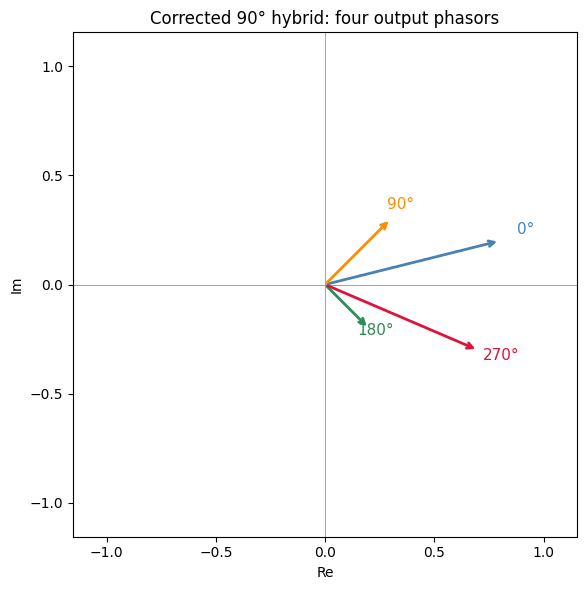

In [5]:
Es_ideal, Elo_ideal = 1+0j, 0.6+0.4j
outs_ideal = hyb.optical_hybrid_90deg_corrected(Es_ideal, Elo_ideal)

fig, ax = plt.subplots(figsize=(6,6))
colors = ['steelblue','darkorange','seagreen','crimson']
labels = ['0°','90°','180°','270°']
for val, c, lab in zip(outs_ideal, colors, labels):
    ax.annotate('', xy=(val.real, val.imag), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2))
    ax.text(val.real*1.15, val.imag*1.15, lab, color=c, fontsize=11, ha='center')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
lim = max(abs(o) for o in outs_ideal) * 1.4
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_aspect('equal')
ax.set_xlabel('Re'); ax.set_ylabel('Im')
ax.set_title('Corrected 90° hybrid: four output phasors')
plt.tight_layout()
plt.savefig('hybrid_phasor_diagram.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Parameter Sweep: Phase Imbalance Degrades I/Q Orthogonality

`phase_imbalance_iq` models a real hardware nonideality (the I and Q branches
not being exactly 90 degrees apart). Sweep it and watch the recovered I/Q
constellation for a fixed QPSK-like set of (Es, Elo) phase relationships
distort from a clean square into a skewed parallelogram.


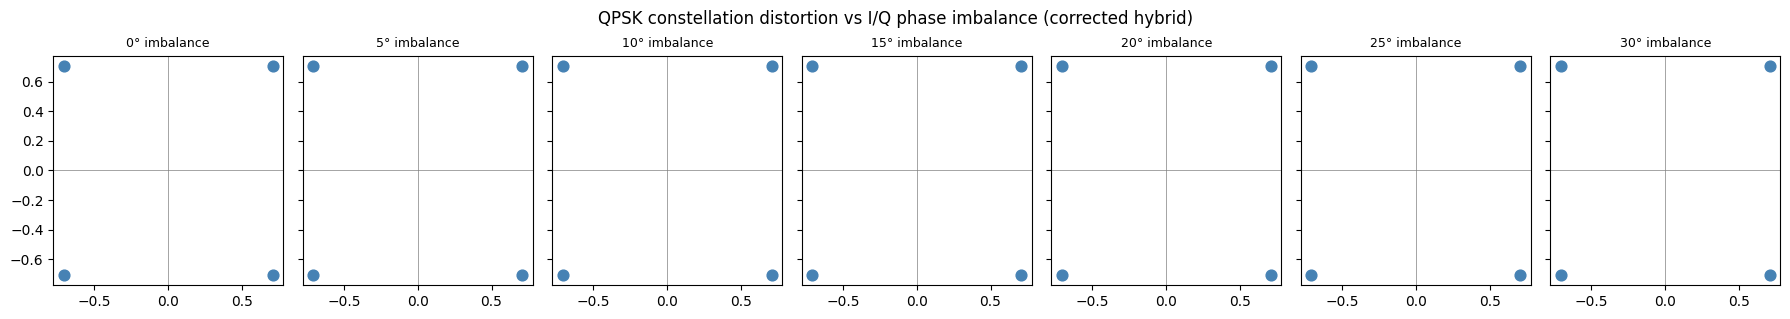

In [6]:
phi_imbalance_deg = np.linspace(0, 30, 7)
qpsk_phases = np.array([np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4])
Elo_fixed = 1.0 + 0j

fig, axes = plt.subplots(1, len(phi_imbalance_deg), figsize=(18,3), sharex=True, sharey=True)
for ax, imb_deg in zip(axes, phi_imbalance_deg):
    Is, Qs = [], []
    for phi in qpsk_phases:
        Es_val = np.exp(1j*phi)
        outs = hyb.optical_hybrid_90deg_corrected(Es_val, Elo_fixed,
                                                   phase_imbalance_iq=np.deg2rad(imb_deg))
        I, Q = hyb.iq_from_hybrid_outputs(*outs)
        Is.append(I); Qs.append(Q)
    ax.scatter(Is, Qs, c='steelblue', s=60)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(f'{imb_deg:.0f}° imbalance', fontsize=9)
    ax.set_aspect('equal')
fig.suptitle('QPSK constellation distortion vs I/Q phase imbalance (corrected hybrid)')
plt.tight_layout()
plt.savefig('hybrid_imbalance_sweep.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Engineering Interpretation

- The 90-degree hybrid trades **hardware complexity for speed**: once built,
  I/Q comes out directly from balanced photodetection -- no iterative
  algorithm needed, unlike `dgs/gs_core.py`'s TD-GS.
- It **requires** a phase-locked LO laser. That's real cost, alignment
  sensitivity, and an extra failure mode (LO drift, LO phase noise) --
  exactly what `dgs/sbir_portfolio.py`'s P2 "no_local_oscillator_advantage"
  section argues TD-GS avoids.
- Phase/amplitude imbalance (§6) is a real, unavoidable hardware
  nonideality -- production hybrids are specified with imbalance tolerances
  (typically a few degrees / <1 dB) precisely because of the constellation
  distortion shown above.
- The bug found in §3 is a good reminder: a numerically-plausible-looking
  ported script can still fail the ONE thing it's supposed to do (recover an
  independent Q) while still "running" -- it takes an explicit derivation +
  check to catch, not just eyeballing the code.


## 8. Research Discussion

This notebook's corrected hybrid is now a genuine, independent baseline for
comparing against this repo's TD-GS approach on equal footing:
- **Accuracy**: does TD-GS's recovered I/Q (via `dgs.gs_core.retrieve_phase`)
  match a hybrid+LO receiver's I/Q at the same SNR, for the same QPSK signal?
- **Latency**: hybrid+balanced-detection is a single linear operation;
  TD-GS needs ~50 GS iterations (`dgs.gs_core`). At what iteration count
  does TD-GS's *accuracy* cross over the hybrid's, if ever, at a given SNR?
- **Hardware cost**: hybrid needs an LO laser + 4 photodetectors + phase-lock
  electronics; TD-GS needs 2 dispersive fiber paths + 2 photodetectors, no
  laser. This asymmetry is `dgs/sbir_portfolio.py` P2/P7's core argument --
  now there's simulated numbers to actually check it against, not just prose.


## 9. Possible Experiments

1. Feed the SAME synthetic QPSK signal (`dgs.gs_core.make_measurements`)
   through both this hybrid model (with realistic LO phase noise added) and
   TD-GS, and directly compare recovered constellations at matched SNR.
2. Sweep LO phase noise (a random walk added to `phase_imbalance_slo` per
   symbol) and find the noise level at which the hybrid's constellation
   degrades to TD-GS's baseline accuracy.
3. If real bench access materializes (per [[user_background]]'s I1/I2
   measurement plan), a real 90-degree hybrid module's actual imbalance
   spec sheet could replace the illustrative sweep in §6 with real numbers.


## 10. Future Improvements

- Port `save_optical_hybrid_outputs.m`'s CSV-writing behavior into
  `dgs/optical_hybrid_90deg.py` if a direct MATLAB-output comparison is
  ever needed (skipped here since this notebook's SymPy/numerical checks
  already cover correctness more rigorously than a CSV diff would).
- Add polarization-diverse hybrid support (real coherent receivers use TWO
  90-degree hybrids, one per polarization) if this ever needs to model a
  full dual-polarization coherent receiver rather than a single-pol toy.
- Wire this module into `dgs/sbir_portfolio.py` P7 as a cited baseline
  implementation once the research-discussion experiments in §8-9 produce
  actual comparison numbers, not before -- avoid citing an unrun comparison
  as if it were a result.
